In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# Bootstrap
Parametric and non-parametric

1. а) Пусть Xi ∼ N(μ, 1), θ = e^μ, б) Xi ∼ R[0, θ]. Пусть в обоих случаях θb – ОМП. Постройте
гистограмму для θb∗i
а) для параметрического б) для непараметрического бутстрэпа и cравните ее с
плотностью истинного распределения θb (логнормальным распределением, которое есть в Python).
Также сравните гистограмму θ∗i − θb с плотностью θb− θ.

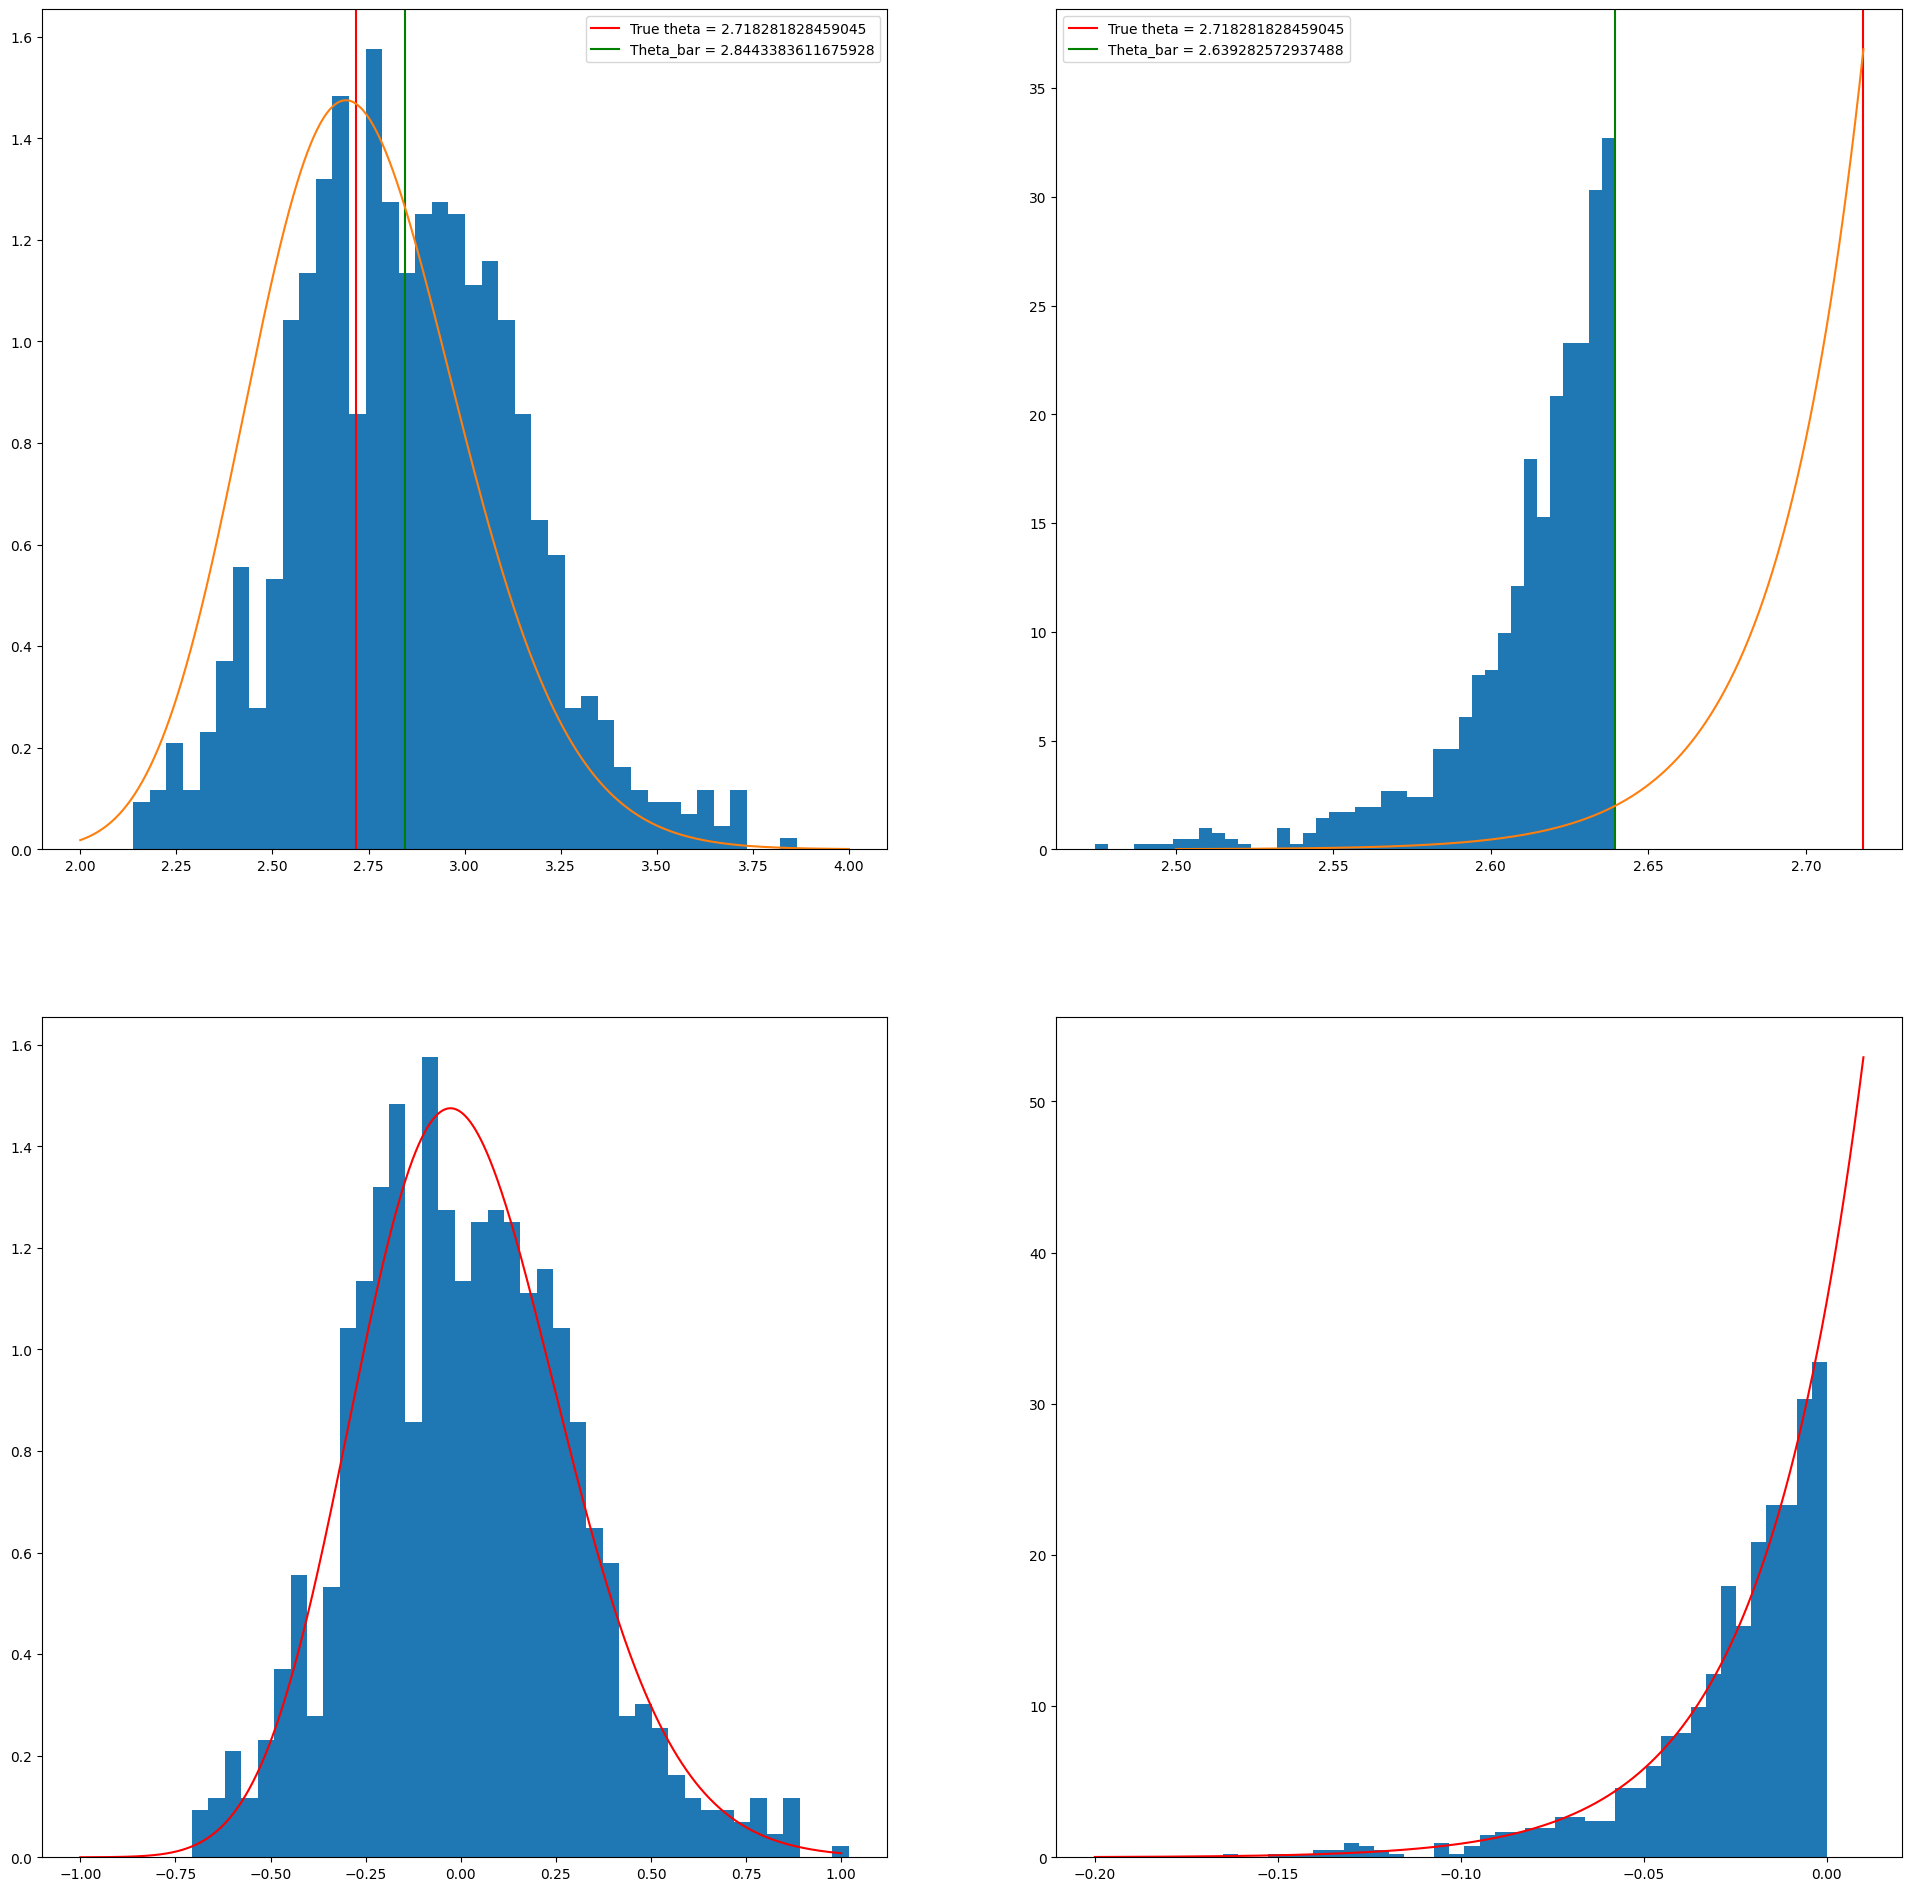

In [ ]:
#пункт а
n = 100
N = 1000
mu = 1
theta = np.exp(mu)

fig, axes = plt.subplots(2, 2, figsize = (24, 24))

x_data = stats.norm.rvs(mu, 1, n)
r = stats.uniform.rvs(scale = theta, size = n)
mean = np.mean(x_data)
r_max = max(r)

theta_bar_x = np.exp(mean)
theta_star_x = np.zeros(N)

theta_bar_r = r_max
theta_star_r = np.zeros(N)

for i in range(N):
  x_star = stats.norm.rvs(mean, 1, n)
  r_star = stats.uniform.rvs(scale = theta_bar_r, size = n)
  theta_star_x[i] = np.exp(np.mean(x_star))
  theta_star_r[i] = np.max(r_star)

sigma_star_x = np.sqrt((n/N)*np.sum((theta_star_x-theta_bar_x)**2))
sigma_star_r = np.sqrt((n/N)*np.sum((theta_star_r-theta_bar_r)**2))

x = np.linspace(2, 4, 1000)
axes[0, 0].hist(theta_star_x, density = True, bins= 40)
axes[0, 0].axvline(theta, color = 'red', label = f'True theta = {theta}')
axes[0, 0].axvline(theta_bar_x, color = 'green', label = f'Theta_bar = {theta_bar_x}')
axes[0, 0].plot(x, stats.lognorm.pdf(x, s = np.sqrt(1/n), scale = np.exp(mu)))
axes[0, 0].legend()

x1 = np.linspace(-1 ,1, 1000)
axes[1, 0].hist(theta_star_x - theta_bar_x, density= True, bins = 40)
axes[1, 0].plot(x1, stats.lognorm.pdf(x1+ theta, s = np.sqrt(1/n), scale = theta), color = 'red')

y = np.linspace(2.5 , theta, 1000)
axes[0, 1].hist(theta_star_r, density = True, bins  =40)
axes[0, 1].axvline(theta, color = 'red', label = f'True theta = {theta}')
axes[0, 1].axvline(theta_bar_r, color = 'green', label = f'Theta_bar = {theta_bar_r}')
axes[0, 1].plot(y, n*(y**(n-1)/(theta**n)))
axes[0, 1].legend()

y1 = np.linspace(-0.2, 0.01, 1000)
axes[1, 1].hist(theta_star_r - theta_bar_r, density= True, bins = 40)
axes[1, 1].plot(y1, n*((y1 + theta)**(n-1)/(theta**n)), color = 'red')

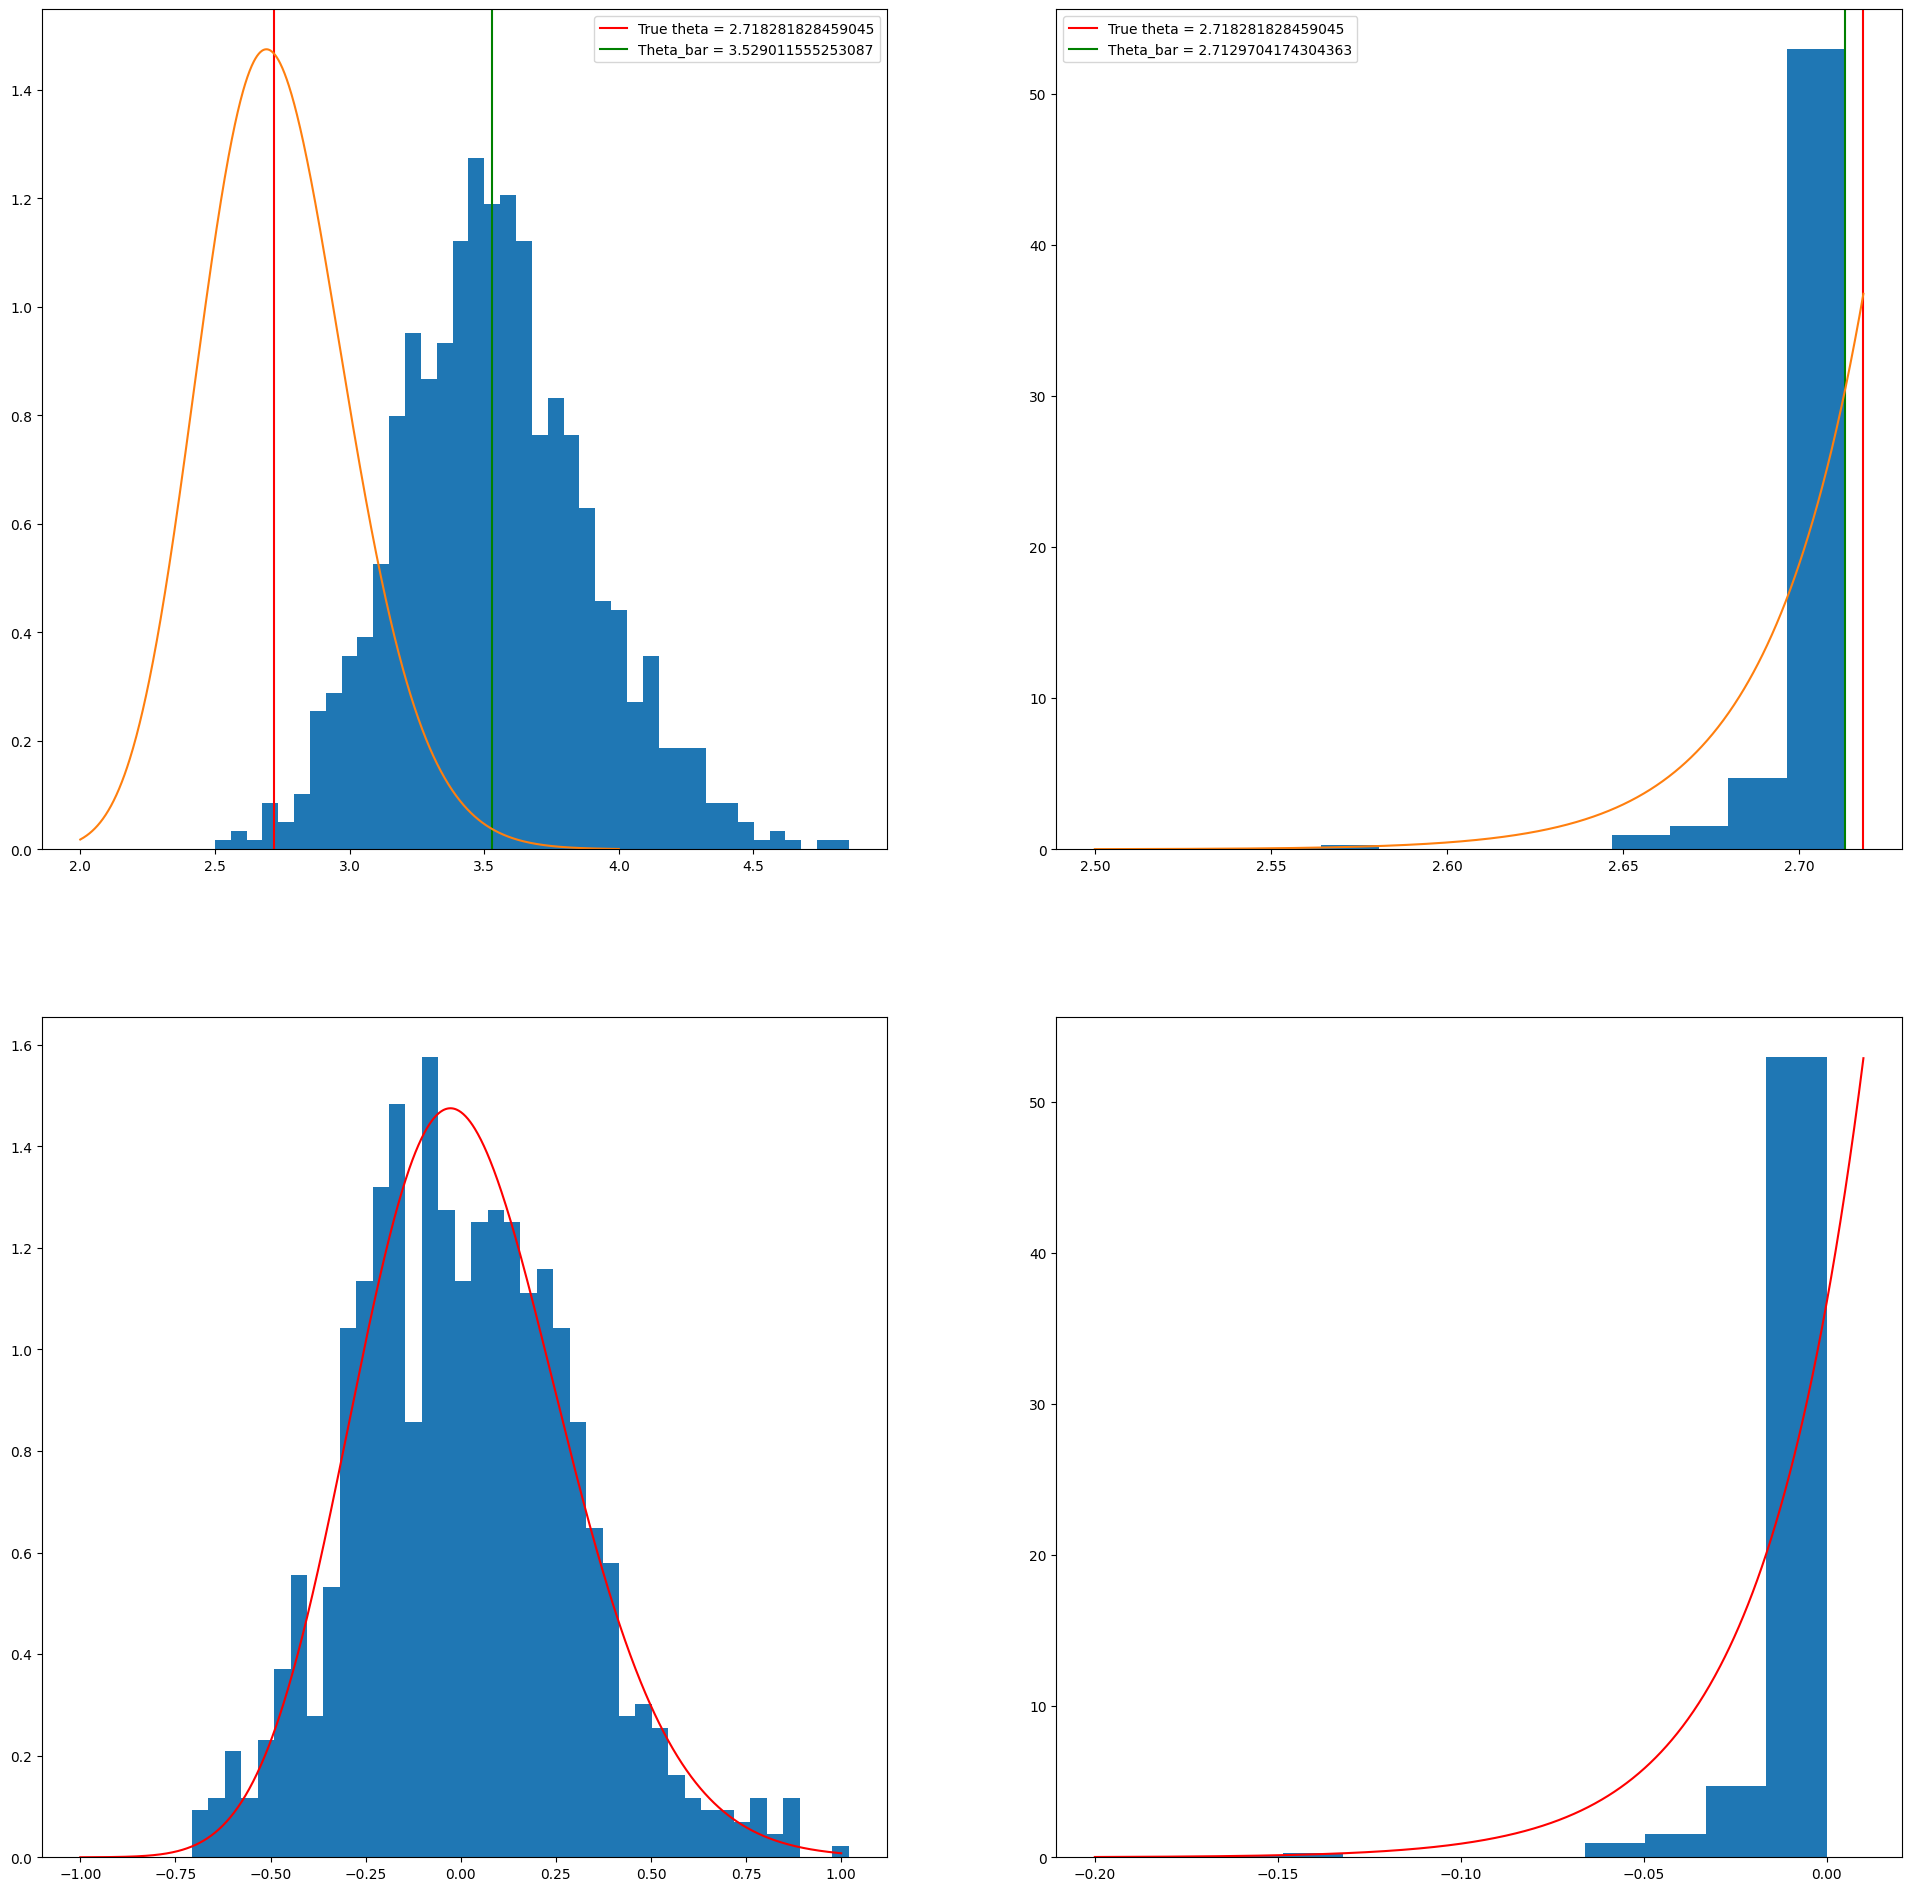

In [ ]:
#пункт б
n = 100
N = 1000
mu = 1
theta = np.exp(mu)

fig, axes = plt.subplots(2, 2, figsize = (24, 24))

x_data = stats.norm.rvs(mu, 1, n)
r = stats.uniform.rvs(scale = theta, size = n)
mean = np.mean(x_data)
r_max = max(r)

theta_bar_x_np = np.exp(mean)
theta_star_x_np = np.zeros(N)

theta_bar_r_np = r_max
theta_star_r_np = np.zeros(N)

for i in range(N):
  x_star_np = np.random.choice(x_data, size = n)
  r_star_np = np.random.choice(r, size = n)
  theta_star_x_np[i] = np.exp(np.mean(x_star_np))
  theta_star_r_np[i] = np.max(r_star_np)

sigma_star_x_np =np.sqrt( (n/N)*np.sum((theta_star_x_np-theta_bar_x_np)**2))
sigma_star_r_np = np.sqrt((n/N)*np.sum((theta_star_r_np-theta_bar_r_np)**2))

x = np.linspace(2, 4, 1000)
axes[0, 0].hist(theta_star_x_np, density = True, bins= 40)
axes[0, 0].axvline(theta, color = 'red', label = f'True theta = {theta}')
axes[0, 0].axvline(theta_bar_x_np, color = 'green', label = f'Theta_bar = {theta_bar_x_np}')
axes[0, 0].plot(x, stats.lognorm.pdf(x, s = np.sqrt(1/n), scale = np.exp(mu)))
axes[0, 0].legend()

x1 = np.linspace(-1 ,1, 1000)
axes[1, 0].hist(theta_star_x - theta_bar_x, density= True, bins = 40)
axes[1, 0].plot(x1, stats.lognorm.pdf(x1+ theta, s = np.sqrt(1/n), scale = theta), color = 'red')

y = np.linspace(2.5 , theta, 1000)
axes[0, 1].hist(theta_star_r_np, density = True)
axes[0, 1].axvline(theta, color = 'red', label = f'True theta = {theta}')
axes[0, 1].axvline(theta_bar_r_np, color = 'green', label = f'Theta_bar = {theta_bar_r_np}')
axes[0, 1].plot(y, n*(y**(n-1)/(theta**n)))
axes[0, 1].legend()

y1 = np.linspace(-0.2, 0.01, 1000)
axes[1, 1].hist(theta_star_r_np - theta_bar_r_np, density= True)
axes[1, 1].plot(y1, n*((y1 + theta)**(n-1)/(theta**n)), color = 'red')

2. В предыдущей задаче построить а) точные интервалы на основе данных статистик б) параметри-
ческие bootstrap интервалы во всех трех случаях, в) непараметрические bootstrap интервалы во всех трех случаях.

In [ ]:
a = 0.05
k = 100
n = 100
N = 100
mu = 1
theta = np.exp(mu)
q = stats.norm.ppf(1-a/2)
#пункт а
acc_x = 0
acc_r = 0
for _ in range(k):
  x_data = stats.norm.rvs(mu, 1, n)
  r_data = stats.uniform.rvs(scale=theta,size=n)
  x_mean = np.mean(x_data)
  r_max = max(r_data)
  low_x = np.exp(x_mean - q/np.sqrt(n))
  up_x = np.exp(x_mean + q/np.sqrt(n))
  low_r = r_max
  up_r = r_max*(a)**(-1/n)
  if low_x<theta<up_x:
    acc_x+=1
  if low_r<theta<up_r:
    acc_r+=1
print(f'Acceptance for x ={acc_x/k}')
print(f'Acceptance for r = {acc_r/k}')

#пункт б
print('')
acc1 = acc2 = acc3 = 0
acc1_r=acc2_r=acc3_r=0
for runs in range(k):
  x_data = stats.norm.rvs(mu, 1, n)
  r_data = stats.uniform.rvs(scale = theta, size = n)
  x_mean = np.mean(x_data)
  r_max = max(r_data)

  theta_bar_x = np.exp(x_mean)
  theta_star_x = np.zeros(N)

  theta_bar_r = r_max
  theta_star_r = np.zeros(N)

  for i in range(N):
    x_star = stats.norm.rvs(x_mean, 1, n)
    r_star = stats.uniform.rvs(scale = theta_bar_r, size = n)
    theta_star_x[i] = np.exp(np.mean(x_star))
    theta_star_r[i] = np.max(r_star)

  sigma_star_x = np.sqrt((n/N)*np.sum((theta_star_x-theta_bar_x)**2))
  sigma_star_r = np.sqrt((n/N)*np.sum((theta_star_r-theta_bar_r)**2))

  q = stats.norm.ppf(1-a/2)

  low1 = theta_bar_x - sigma_star_x*q/np.sqrt(n)
  up1 = theta_bar_x + sigma_star_x*q/np.sqrt(n)

  theta_star_x.sort()
  low2 = theta_star_x[int(a*N/2)]
  up2 = theta_star_x[N - int(a*N/2)]

  low3 = 2*theta_bar_x - theta_star_x[N - int(a*N/2)]
  up3 = 2*theta_bar_x - theta_star_x[int(a*N/2)]

  if low1 < theta < up1:
    acc1+=1
  if low2<theta < up2:
    acc2+=1
  if low3 < theta< up3:
    acc3+=1
  ## case for r
  low1 = theta_bar_r - sigma_star_r*q/np.sqrt(n)
  up1 = theta_bar_r + sigma_star_r*q/np.sqrt(n)

  theta_star_r.sort()
  low2 = theta_star_r[int(a*N/2)]
  up2 = theta_star_r[N - int(a*N/2)]

  low3 = 2*theta_bar_r - theta_star_r[N - int(a*N/2)]
  up3 = 2*theta_bar_r - theta_star_r[int(a*N/2)]

  if low1 < theta < up1:
    acc1_r+=1
  if low2<theta < up2:
    acc2_r+=1
  if low3 < theta< up3:
    acc3_r+=1
print('FOR N(mu,1)')
print(f'Acceptance in parametric case 1 = {acc1/k}')
print(f'Acceptance in parametric case 2 = {acc2/k}')
print(f'Acceptance in parametric case 3 = {acc3/k}')
print('FOR R[0, theta]')
print(f'Acceptance in parametric case 1 = {acc1_r/k}')
print(f'Acceptance in parametric case 2 = {acc2_r/k}')
print(f'Acceptance in parametric case 3 = {acc3_r/k}')


#пункт в
print('')

acc1=acc2=acc3 = 0
acc1_r=acc2_r=acc3_r=0
for runs in range(k):
  x_data = stats.norm.rvs(mu, 1, n)
  r = stats.uniform.rvs(scale = theta, size = n)
  mean = np.mean(x_data)
  r_max = max(r)

  theta_bar_x_np = np.exp(mean)
  theta_star_x_np = np.zeros(N)

  theta_bar_r_np = r_max
  theta_star_r_np = np.zeros(N)

  for i in range(N):
    x_star_np = np.random.choice(x_data, size = n)
    r_star_np = np.random.choice(r, size = n)
    theta_star_x_np[i] = np.exp(np.mean(x_star_np))
    theta_star_r_np[i] = np.max(r_star_np)

  sigma_star_x_np =np.sqrt( (n/N)*np.sum((theta_star_x_np-theta_bar_x_np)**2))
  sigma_star_r_np = np.sqrt((n/N)*np.sum((theta_star_r_np-theta_bar_r_np)**2))


  low1_np = theta_bar_x_np - sigma_star_x_np*q/np.sqrt(n)
  up1_np = theta_bar_x_np + sigma_star_x_np*q/np.sqrt(n)

  theta_star_x_np.sort()
  low2_np = theta_star_x_np[int(a*N/2)]
  up2_np = theta_star_x_np[N - int(a*N/2)]

  low3_np = 2*theta_bar_x_np - theta_star_x_np[N - int(a*N/2)]
  up3_np = 2*theta_bar_x_np - theta_star_x_np[int(a*N/2)]

  if low1_np < theta < up1_np:
    acc1+=1
  if low2_np < theta < up2_np:
    acc2+=1
  if low3_np < theta< up3_np:
    acc3+=1

  low1_np = theta_bar_r_np - sigma_star_r_np*q/np.sqrt(n)
  up1_np = theta_bar_r_np + sigma_star_r_np*q/np.sqrt(n)

  theta_star_r_np.sort()
  low2_np = theta_star_r_np[int(a*N/2)]
  up2_np = theta_star_r_np[N - int(a*N/2)]

  low3_np = 2*theta_bar_r_np - theta_star_r_np[N - int(a*N/2)]
  up3_np = 2*theta_bar_r_np - theta_star_r_np[int(a*N/2)]

  if low1_np < theta < up1_np:
    acc1_r+=1
  if low2_np<theta < up2_np:
    acc2_r+=1
  if low3_np < theta< up3_np:
    acc3_r+=1
print('FOR N(mu,1)')
print(f'Acceptance in non-parametric case 1 = {acc1/k}')
print(f'Acceptance in non-parametric case 2 = {acc2/k}')
print(f'Acceptance in non-parametric case 3 = {acc3/k}')
print('FOR R[0,theta]')
print(f'Acceptance in non-parametric case 1 = {acc1_r/k}')
print(f'Acceptance in non-parametric case 2 = {acc2_r/k}')
print(f'Acceptance in non-parametric case 3 = {acc3_r/k}')

Acceptance for x =0.95
Acceptance for r = 0.95

FOR N(mu,1)
Acceptance in parametric case 1 = 0.97
Acceptance in parametric case 2 = 0.96
Acceptance in parametric case 3 = 0.96
FOR R[0, theta]
Acceptance in parametric case 1 = 0.94
Acceptance in parametric case 2 = 0.0
Acceptance in parametric case 3 = 0.95

FOR N(mu,1)
Acceptance in non-parametric case 1 = 0.94
Acceptance in non-parametric case 2 = 0.92
Acceptance in non-parametric case 3 = 0.96
FOR R[0,theta]
Acceptance in non-parametric case 1 = 0.82
Acceptance in non-parametric case 2 = 0.0
Acceptance in non-parametric case 3 = 0.87


3. Построить для медианы распределения Коши а) асимптотический интервал на основе асимпто-
тической нормальности б) непараметрический pivotal bootstrap доверительный интервал. В чем плюс второго интервала в случае, если мы не знаем, что настоящее распределение – Коши?

In [ ]:
n = 100
N = 100
k = 1000
a = 0.05
q = stats.norm.ppf(1-a/2)
theta = 0
acc = 0
acc_b = 0

for _ in range(k):
  x_data = stats.cauchy.rvs(loc = theta, size = n)
  m = np.median(x_data) #theta_bar
  theta_star = np.zeros(N)

  for i in range(N):
    x_i = np.random.choice(x_data, size = n)
    theta_star[i] = np.median(x_i)

  #sigma_star = np.sqrt((n/N)*np.sum((theta_star-m)**2))

  #exact
  if  m - np.pi*q/(2*np.sqrt(n)) < theta < m + np.pi*q/(2*np.sqrt(n)):
    acc+=1
  #non-parametric pivotal bootstrap
  theta_star.sort()
  if 2*m - theta_star[N - int(a*N/2)] < theta < 2*m - theta_star[int(a*N/2)]:
    acc_b += 1

print(f'Acceptance basic = {acc/k}')
print(f'Acceptance bootstrap = {acc_b/k}')


Acceptance basic = 0.953
Acceptance bootstrap = 0.907


4. В файле sydrain.txt приведены данные о годовом уровне осадков в Сиднее. Постройте доверительные интервалы для математического ожидания и медианы распределения.

In [ ]:
data = [146.8,383.0,90.9,178.1,267.5,95.5,156.5,180.0,90.9,139.7,200.2,171.7,187.2,184.9,70.1,58.0,84.1,55.6,133.1,271.8,135.9,71.9,99.4,110.6,47.5,97.8,122.7,58.4,154.4,173.7,118.8,88.0,84.6,171.5,254.3,185.9,137.2,138.9,96.2,85.0,45.2,74.7,264.9,113.8,133.4,68.1,156.4]
mean = np.mean(data)
median = np.median(data)
n = len(data)
N = 1000
a= 0.05
q = stats.norm.ppf(1-a/2)
mean_star = np.zeros(N)
median_star = np.zeros(N)

for i in range(N):
  x_i = np.random.choice(data, size = n)
  mean_star[i] = np.mean(x_i)
  median_star[i] = np.median(x_i)

sigma_mean = np.sqrt((n/N)*np.sum((mean_star-mean)**2))
sigma_median = np.sqrt((n/N)*np.sum((median_star-median)**2))

mean_star.sort()
median_star.sort()

print(f'Normal mean interval : ({mean - sigma_mean*q/np.sqrt(n)}, {mean + sigma_mean*q/np.sqrt(n)})')
print(f'Normal median interval : ({median - sigma_median*q/np.sqrt(n)}, {median + sigma_median*q/np.sqrt(n)})')
print('')
print(f'Percentile mean interval : ({mean_star[int(a*N/2)]}, {mean_star[N - int(a*N/2)]})')
print(f'Percentile median interval : ({median_star[int(a*N/2)]}, {median_star[N - int(a*N/2)]})')
print('')
print(f'Pivotal mean interval : ({2*mean - mean_star[N - int(a*N/2)]}, {2*mean - mean_star[int(a*N/2)]})')
print(f'Pivotal median interval : ({2*median - median_star[N - int(a*N/2)]}, {2*median - median_star[int(a*N/2)]})')

Normal mean interval : (117.81183032613956, 156.00944626960506)
Normal median interval : (104.48146925060871, 161.71853074939128)

Percentile mean interval : (119.10638297872339, 157.61063829787233)
Percentile median interval : (97.8, 154.4)

Pivotal mean interval : (116.2106382978723, 154.71489361702123)
Pivotal median interval : (111.79999999999998, 168.39999999999998)
